In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.DataFrame({
    'IQ' : [80, 60, 70, 120],
    'CGPA' : [8, 9, 5, 7],
    'LPA': [3, 5, 8, 11]
})

df

,IQ,CGPA,LPA
0,80,8,3
1,60,9,5
2,70,5,8
3,120,7,11


In [ ]:
X = df[['IQ', 'CGPA']]
X = (X - X.mean()) / X.std()
X

,IQ,CGPA
0,-0.095059,0.439155
1,-0.855528,1.024695
2,-0.475293,-1.317465
3,1.425880,-0.146385


Initialization (Weights + Baises)

In [ ]:
b1 = np.array([1, 1])
#w1 = np.array([[0, 0], [0, 0]])
#w2 = np.array([[0], [0]])
b2 = np.array([1])
# weight initialized as 0 -> loss remains same
# multiplied by 0.01 to scale, our data (x -> predictors) are also scaled, so that the gradients (partial derivatives) are small.
w1 = np.random.randn(2, 2) * 0.01
w2 = np.random.randn(2, 1) * 0.01
#print(b1); print("\n"); print(w1); print("\n"); print(b2); print("\n"); print(w2)

In [ ]:
b1 = b1.reshape(-1,1)
b2 = b2.reshape(-1, 1)
print(b1.shape)
print(b2.shape)
print(w1.shape)
print(w2.shape)

(2, 1)
(1, 1)
(2, 2)
(2, 1)


For Testing

In [ ]:
o = w1.T @ np.array([df['IQ'][0], df['CGPA'][0]]).reshape(-1, 1) + b1 #dim: (2,2)*(2,1) + (2,1) = (2,1)
o.shape

(2, 1)

In [ ]:
ypred = w2.T @ o + b2 #dim : (1,2)*(2,1) + (1,1) = (1,1)
ypred.shape

(1, 1)

In [ ]:
delLbydelw2_11 = -2*(df['LPA'][0] - ypred)*o[0][0]
delLbydelw2_11[0][0]

np.float64(-4.0)

Main Logic (Forward Propogation + Backward Propogation)

In [ ]:
m = 4 # passing each row at a time
alpha = 0.0001
epochs = 500 # number of full passes of the complete data

avg_loss = []
epochs_count = []

for j in range(epochs):
  print(f"Epoch : {j}")
  loss = []
  for i in range(m):
    # Forward Propogation
    o = w1.T @ np.array([X['IQ'][i], X['CGPA'][i]]).reshape(-1, 1) + b1 # Layer 1
    ypred = w2.T @ o + b2 # layer 2
    yactual = df['LPA'][i]
    # Loss
    l = (yactual - ypred)**2
    #print(f"Loss = {l}")
    loss.append(l)
    # Backward Propogation
    # partial derivatives
    # set 1
    delLbydelw2_11 = -2*(yactual - ypred)*o[0][0]
    delLbydelw2_21 = -2*(yactual - ypred)*o[1][0]
    delLbydelb21 = -2*(yactual - ypred)
    # set 2
    delLbydelw1_11 = -2*(yactual - ypred)*w2[0][0]*X['IQ'][i]
    delLbydelw1_21 = -2*(yactual - ypred)*w2[0][0]*X['CGPA'][i]
    delLbydelb11 = -2*(yactual - ypred)*w2[0][0]
    # set 3
    delLbydelw1_12 = -2*(yactual - ypred)*w2[1][0]*X['IQ'][i]
    delLbydelw1_22 = -2*(yactual - ypred)*w2[1][0]*X['CGPA'][i]
    delLbydelb12 = -2*(yactual - ypred)*w2[1][0]
    # gradient descent updates
    # set 1
    w2[0][0] = w2[0][0] - alpha*delLbydelw2_11[0][0]
    w2[1][0] = w2[1][0] - alpha*delLbydelw2_21[0][0]
    b2[0][0] = b2[0][0] - alpha*delLbydelb21[0][0]
    # set 2
    w1[0][0] = w1[0][0] - alpha*delLbydelw1_11[0][0]
    w1[1][0] = w1[1][0] - alpha*delLbydelw1_21[0][0]
    b1[0][0] = b1[0][0] - alpha*delLbydelb11[0][0]
    # set 3
    w1[0][1] = w1[0][1] - alpha*delLbydelw1_12[0][0]
    w1[1][1] = w1[1][1] - alpha*delLbydelw1_22[0][0]
    b1[1][0] = b1[1][0] - alpha*delLbydelb12[0][0]

  avg_loss.append(np.mean(loss))
  print(f"Avg Loss : {np.mean(loss)}")
  epochs_count.append(j)


Epoch : 0
Avg Loss : 42.12721166394532
Epoch : 1
Avg Loss : 42.06208874272526
Epoch : 2
Avg Loss : 42.00936893786124
Epoch : 3
Avg Loss : 41.95673098994586
Epoch : 4
Avg Loss : 41.90417403893791
Epoch : 5
Avg Loss : 41.85169722735513
Epoch : 6
Avg Loss : 41.799299700261074
Epoch : 7
Avg Loss : 41.74698060525246
Epoch : 8
Avg Loss : 41.69473909244718
Epoch : 9
Avg Loss : 41.642574314472874
Epoch : 10
Avg Loss : 41.59048542645606
Epoch : 11
Avg Loss : 41.538471586011795
Epoch : 12
Avg Loss : 41.486531953233964
Epoch : 13
Avg Loss : 41.43466569068603
Epoch : 14
Avg Loss : 41.38287196339246
Epoch : 15
Avg Loss : 41.33114993883056
Epoch : 16
Avg Loss : 41.279498786923
Epoch : 17
Avg Loss : 41.22791768003063
Epoch : 18
Avg Loss : 41.17640579294617
Epoch : 19
Avg Loss : 41.124962302888065
Epoch : 20
Avg Loss : 41.073586389495205
Epoch : 21
Avg Loss : 41.02227723482186
Epoch : 22
Avg Loss : 40.97103402333332
Epoch : 23
Avg Loss : 40.919855941902
Epoch : 24
Avg Loss : 40.86874217980402
Epoch : 

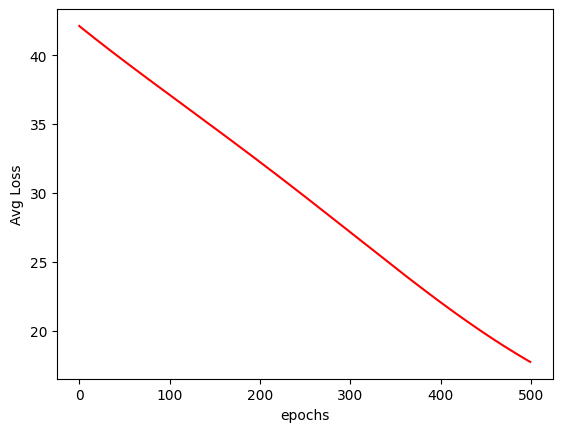

In [ ]:
import matplotlib.pyplot as plt

plt.plot(epochs_count, avg_loss, c = "red")
plt.xlabel("epochs"); plt.ylabel("Avg Loss")
plt.show()